## Introduction to NetworkX
NetworkX is a powerful library in Python for creating, manipulating, and studying the structure, dynamics, and functions of complex networks. Here’s a quick guide to get started with the basics.

In [1]:
#To work with NetworkX, first ensure it’s installed. Run the following in your terminal
# pip install networkx

import networkx as nx

#To plot your networks
import matplotlib.pyplot as plt

In [2]:
from gurobipy import *
import numpy as np

import random
np.random.seed(33)

### Creating a New Network
NetworkX provides different types of graphs:
- **Graph()**: for undirected graphs
- **DiGraph()**: for directed graphs

In [3]:
# Undirected graph
G = nx.Graph()

# Directed graph
DG = nx.DiGraph()

### Adding Nodes
Nodes can be any object, such as integers, strings, or custom objects. You can add nodes individually or in a batch.

In [4]:
# Add a single node
G.add_node(1, pos =(10,11))

# Add multiple nodes
G.add_nodes_from([2,3,4])

### 注释：关于 `pos`、坐标维度与批量添加节点

- 图本身是抽象的顶点/边结构（`V(G)`/`E(G)`），并不内在包含几何坐标。`pos` 只是一个用于可视化的节点属性，通常为二维坐标 `(x, y)`，以便 `nx.draw(..., pos=pos)` 绘图。

- 代码中 `G.add_node(1, pos=(10,11))` 是在添加节点时同时给该节点设置 `pos` 属性；而 `G.add_nodes_from([2,3,4])` 只是把节点加入图中，并没有为这些节点指定 `pos`。这就是为什么后面有一个单独的 `coordinates` 字典（或在循环里为每个节点设置 `pos`）来填充位置。

- 常见做法（三种）：
  1. 先建立 `pos` 字典，然后依节点绘图：
     ```python
     pos = {1:(10,11), 2:(2,3), 3:(4,5)}
     G.add_nodes_from(pos.keys())
     nx.draw(G, pos=pos, with_labels=True)
     ```
  2. 一次性添加带属性的节点：
     ```python
     G.add_nodes_from([(2, {'pos':(2,3)}), (3, {'pos':(4,5)})])
     pos = nx.get_node_attributes(G, 'pos')
     nx.draw(G, pos=pos)
     ```
  3. 先添加节点再赋属性（适合程序生成位置）：
     ```python
     G.add_nodes_from([1,2,3,4])
     for n,(x,y) in coordinates.items():
         G.nodes[n]['pos'] = (x,y)
     pos = nx.get_node_attributes(G, 'pos')
     nx.draw(G, pos=pos)
     ```

- 关于维度：`pos` 常为二维，因为 `nx.draw` 使用 matplotlib 的 2D 绘图。你可以把 3D 坐标存为属性（例如 `pos3`），但若要三维可视化需使用 `mpl_toolkits.mplot3d`、Plotly 等库手动绘制。

- 小结：Notebook 中先用 `G.add_node(..., pos=...)` 示范单个节点带坐标，随后用 `G.add_nodes_from([2,3,4])` 只是为示意批量添加节点；真实可视化时作者在后续代码用 `coordinates` 字典为这些节点设置了坐标并用 `nx.get_node_attributes(G1, 'pos')` 提取 `pos` 绘图。

如果你愿意，我可以把上面的三种做法加入示例代码单元并演示（不改原有示例的情况下新增示例单元）。

### Adding Edges
Edges connect nodes. In an undirected graph, an edge from A to B is identical to an edge from B to A. In directed graphs, the direction matters.

In [5]:
# Add an edge between two nodes (undirected)
G.add_edge(1,2)

# Add multiple edges
G.add_edges_from([(2,3), (3,4)])

# Add directed edges
DG.add_edge(1,2)
DG.add_edges_from([(2,3),(3,4), (1,3)])

### Drawing the Network
We can use NetworkX’s drawing tools to visualize the network. Use the following code to draw undirected and directed graphs.

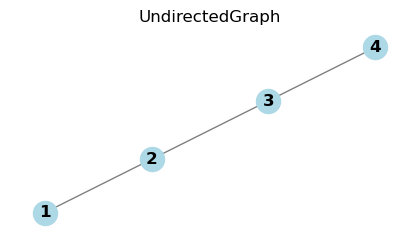

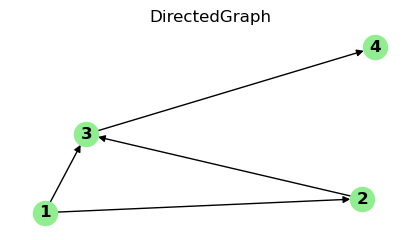

In [6]:
# Draw the undirected graph
plt.figure(figsize=(4,2))
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', font_weight='bold')
plt.title("UndirectedGraph")
plt.show()

# Draw the directed graph
plt.figure(figsize=(4,2))
nx.draw(DG, with_labels=True, node_color='lightgreen', edge_color='black', font_weight='bold', arrows=True)
plt.title("DirectedGraph")
plt.show()

### Creating a Network from Given Node Coordinates

The below example shows a directed network with 10 nodes. The x and y coordinates are given for the nodes (randomly generated).

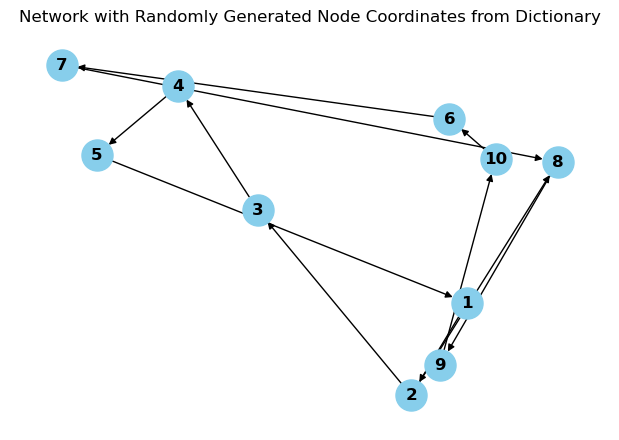

In [7]:
# Number of nodes
num_nodes = 10

# Generate random coordinates and store in a dictionary
coordinates = {i: (random.uniform(-10, 10), random.uniform(-10, 10)) for i in range(1, num_nodes + 1)}

# Create an undirected graph
G1 = nx.DiGraph()

# Add nodes to the graph using coordinates from the dictionary
for node, (x, y) in coordinates.items():
    G1.add_node(node, pos=(x, y))

# Add some edges between nodes
edges = [(1, 2), (2, 3), (2,8), (3, 4), (4, 5), (5, 1), (6, 7), (7, 8), (8, 9), (9, 10), (10, 6)]
G1.add_edges_from(edges)

# Extract positions for drawing
pos = nx.get_node_attributes(G1, 'pos')

# Draw the network
plt.figure(figsize=(6, 4))
nx.draw(G1, pos, with_labels=True, node_size=500, node_color='skyblue', font_weight='bold')
plt.title("Network with Randomly Generated Node Coordinates from Dictionary")
plt.show()

## Calculating Distance
Here are two functions that calculate the distances between each pair of nodes using both Euclidean and Manhattan distance formulas. Each function takes the dictionary of coordinates as input and returns a dictionary of distances between node pairs.

In [8]:
import math

# Number of nodes
num_nodes = 10

# Generate random coordinates and store in a dictionary
coordinates = {i: (random.uniform(-10, 10), random.uniform(-10, 10)) for i in range(1, num_nodes + 1)}

def euclidean_distances(coordinates):
    """
    Calculate the Euclidean distance between each pair of nodes.

    Parameters:
    - coordinates: A dictionary with nodes as keys and (x, y) tuples as values.

    Returns:
    - A dictionary where keys are tuples representing node pairs and values are the Euclidean distances.
    """
    distances = {}
    for node1, (x1, y1) in coordinates.items():
        for node2, (x2, y2) in coordinates.items():
            if node1 < node2:  # Avoid duplicate pairs and self-distance
                dist = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
                distances[(node1, node2)] = dist
    return distances

def manhattan_distances(coordinates):
    """
    Calculate the Manhattan distance between each pair of nodes.

    Parameters:
    - coordinates: A dictionary with nodes as keys and (x, y) tuples as values.

    Returns:
    - A dictionary where keys are tuples representing node pairs and values are the Manhattan distances.
    """
    distances = {}
    for node1, (x1, y1) in coordinates.items():
        for node2, (x2, y2) in coordinates.items():
            if node1 < node2:  # Avoid duplicate pairs and self-distance
                dist = abs(x2 - x1) + abs(y2 - y1)
                distances[(node1, node2)] = dist
    return distances

# Example usage
euclidean_dist = euclidean_distances(coordinates)
manhattan_dist = manhattan_distances(coordinates)

print("Euclidean Distances:")
for nodes, dist in euclidean_dist.items():
    print(f"Distance between {nodes}: {dist:.2f}")

print("\nManhattan Distances:")
for nodes, dist in manhattan_dist.items():
    print(f"Distance between {nodes}: {dist:.2f}")


Euclidean Distances:
Distance between (1, 2): 17.20
Distance between (1, 3): 9.99
Distance between (1, 4): 7.49
Distance between (1, 5): 6.45
Distance between (1, 6): 12.47
Distance between (1, 7): 13.51
Distance between (1, 8): 7.28
Distance between (1, 9): 8.21
Distance between (1, 10): 8.24
Distance between (2, 3): 12.35
Distance between (2, 4): 9.72
Distance between (2, 5): 11.48
Distance between (2, 6): 11.90
Distance between (2, 7): 9.00
Distance between (2, 8): 20.11
Distance between (2, 9): 16.28
Distance between (2, 10): 9.10
Distance between (3, 4): 6.82
Distance between (3, 5): 4.77
Distance between (3, 6): 2.49
Distance between (3, 7): 4.48
Distance between (3, 8): 16.61
Distance between (3, 9): 15.35
Distance between (3, 10): 6.07
Distance between (4, 5): 2.63
Distance between (4, 6): 8.51
Distance between (4, 7): 7.88
Distance between (4, 8): 11.70
Distance between (4, 9): 9.20
Distance between (4, 10): 1.09
Distance between (5, 6): 6.90
Distance between (5, 7): 7.22
Dist

## Calculating the Shortest Path
NetworkX includes functions to calculate the shortest path. To find the shortest path between two nodes:

In [9]:
# Shortest path in a directed graph
path = nx.shortest_path(G1, source=1, target=10)
print("ShortestPath", path)

# Length of shortest path in undirected graph
distance = nx.shortest_path_length(G1, source=1, target=10)
print(distance)

ShortestPath [1, 2, 8, 9, 10]
4


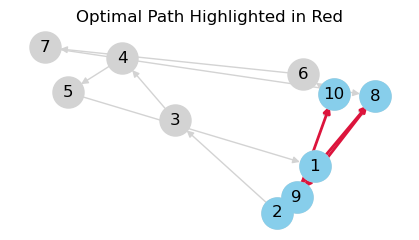

In [10]:
# Assuming G1 is your original graph and pos is your position dictionary
# Find the shortest path between nodes 1 and 10, where "path = nx.shortest_path(G1, source=1, target=10)""

# Convert path nodes to edges
path_edges = list(zip(path, path[1:]))

# Draw the original graph with light colors
plt.figure(figsize=(4,2))
nx.draw(G1, pos, with_labels=True, node_size=500, node_color='lightgray', edge_color='lightgray')

# Draw the shortest path with a highlighted color
nx.draw_networkx_nodes(G1, pos, nodelist=path, node_color='skyblue', node_size=500)
nx.draw_networkx_edges(G1, pos, edgelist=path_edges, edge_color='crimson', width=2)

plt.title("Optimal Path Highlighted in Red")
plt.show()